In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load & Explore & Clean Data

In [106]:
df = pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [107]:
df.shape

(7043, 21)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [109]:
print(df.isnull().sum().sum())

0


In [110]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [111]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [112]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [113]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [114]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [115]:
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [116]:
df.dropna(inplace=True)
df.shape

(7032, 21)

In [117]:
df.isnull().sum().sum()

np.int64(0)

In [118]:
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [119]:
# Check unique values in Churn
print(df['Churn'].unique())
print(df['Churn'].value_counts())

[0 1]
Churn
0    5163
1    1869
Name: count, dtype: int64


### Data Visualization

#### 1. Churn Distribution

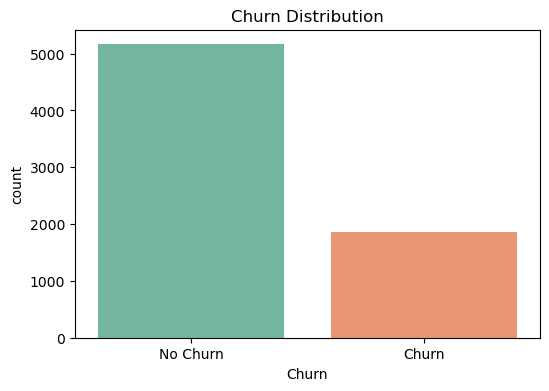

In [120]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title("Churn Distribution")
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

#### 2. Churn by Contract Type

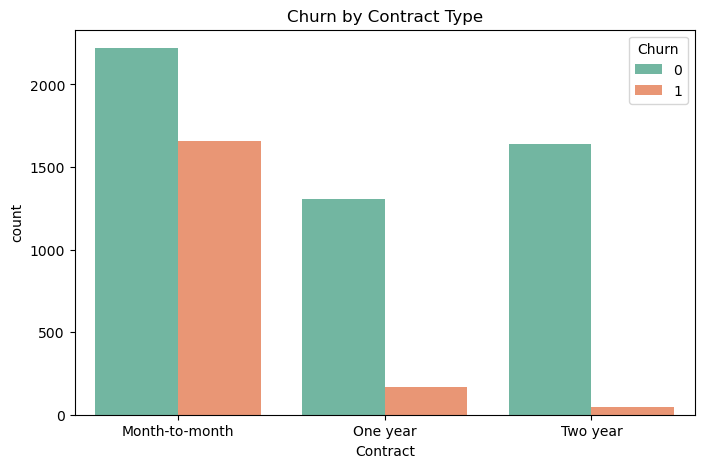

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Contract'], hue=df['Churn'], palette='Set2')
plt.title("Churn by Contract Type")
plt.show()

#### 3. Monthly Charges vs Churn

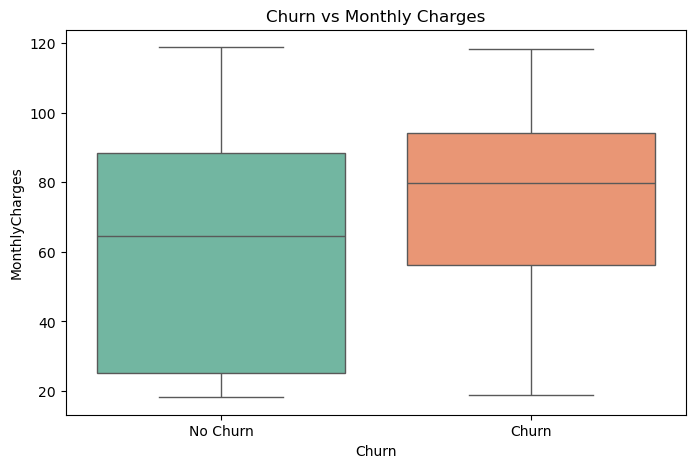

In [122]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'], palette='Set2')
plt.title('Churn vs Monthly Charges')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

#### 4.  Tenure vs Churn

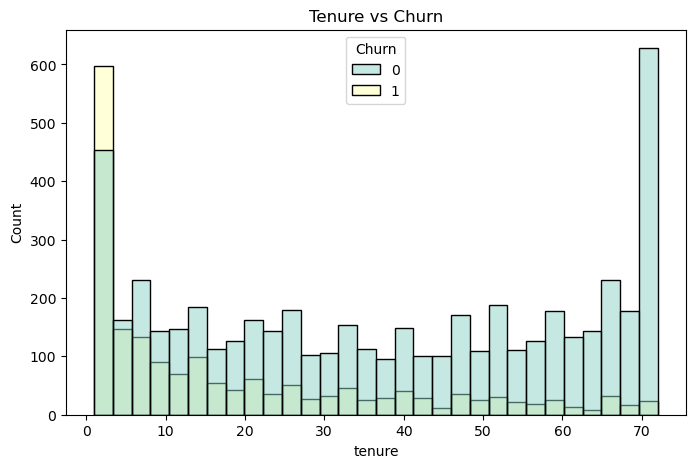

In [123]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set3')
plt.title('Tenure vs Churn')
plt.show()

#### 5 — Correlation Heatmap

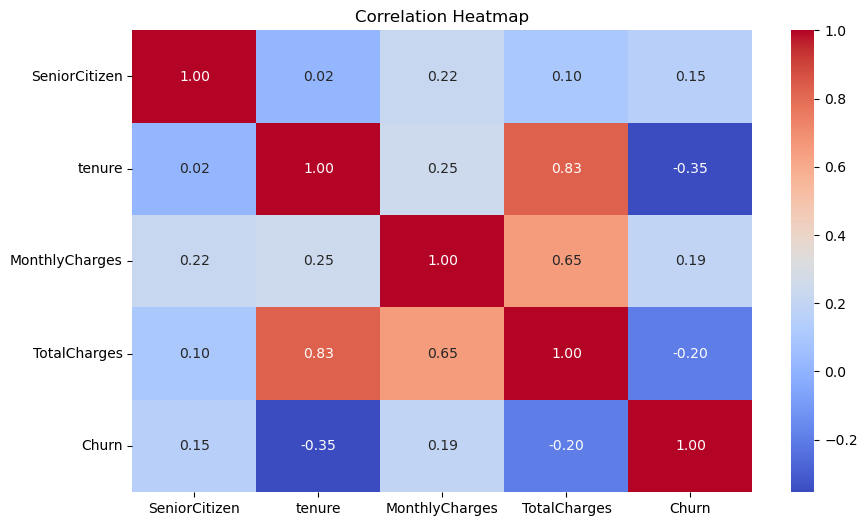

In [124]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Feature Engineering 

In [125]:
print(df.select_dtypes(include='object').columns.tolist())
print("\nTotal object columns:", df.select_dtypes(include='object').shape[1])

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Total object columns: 15


In [126]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Selection   
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Save Model
import joblib

print("All Libraries Imported Successfully")


All Libraries Imported Successfully


In [127]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [128]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [129]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [130]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)


In [132]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Done")


Scaling Done


### Model Building 

In [133]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [134]:
lr_pred = lr.predict(X_test)

In [135]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7938877043354655


In [136]:
rf = RandomForestClassifier(
    n_estimators=200,      # more trees
    max_depth=10,          # control tree depth
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [137]:
rf_pred = rf.predict(X_test)

In [138]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7931769722814499


In [139]:
from sklearn.model_selection import GridSearchCV

# Define parameters to try
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy: 0.8055111111111112


In [140]:
# Train with best parameters
best_rf = RandomForestClassifier(
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train, y_train)
best_rf_pred = best_rf.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, best_rf_pred))

Final Model Accuracy: 0.7896233120113717


In [141]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

print("=== Random Forest (Best) ===")
print(classification_report(y_test, best_rf_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407

=== Random Forest (Best) ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [142]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


In [143]:
# Train with balanced data
best_rf_sm = RandomForestClassifier(
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf_sm.fit(X_train_sm, y_train_sm)
best_rf_sm_pred = best_rf_sm.predict(X_test)

print("Accuracy after SMOTE:", accuracy_score(y_test, best_rf_sm_pred))
print("\nClassification Report:")
print(classification_report(y_test, best_rf_sm_pred))

Accuracy after SMOTE: 0.7739872068230277

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407



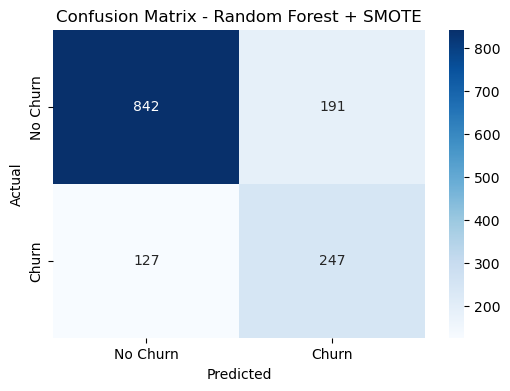

In [144]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, best_rf_sm_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest + SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

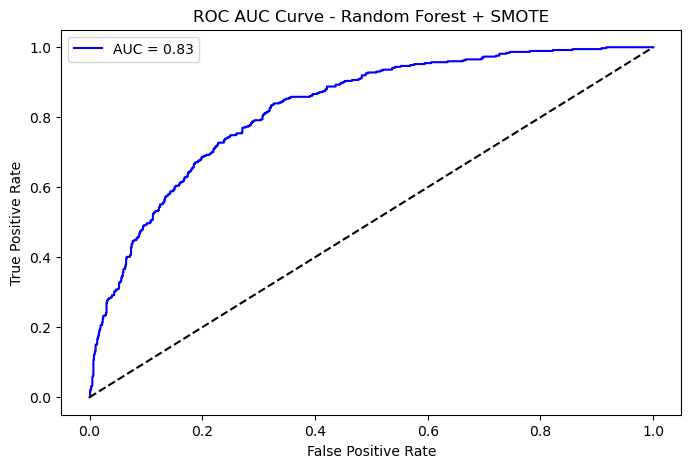

ROC AUC Score: 0.8264141615459877


In [145]:
fpr, tpr, _ = roc_curve(y_test, best_rf_sm.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, best_rf_sm.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve - Random Forest + SMOTE')
plt.legend()
plt.show()

print("ROC AUC Score:", auc)

In [146]:
import joblib

# Save model and scaler
joblib.dump(best_rf_sm, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model Saved ✅")
print("Files created:")
print("  → churn_model.pkl")
print("  → scaler.pkl")

Model Saved ✅
Files created:
  → churn_model.pkl
  → scaler.pkl
